In [ ]:
"""
locate_surface_events_2025.py
-------------------------------
Scans all daily common-detection CSVs for 2025, filters for:
  - pure "su" events (every station in all_classes == 'su')
  - detected at > 8 stations

For each qualifying event:
  1. Downloads vertical-component waveforms from IRIS FDSN
  2. Preprocesses: demean → taper → resample 50 Hz → bandpass 1–8 Hz → SNR filter
  3. Computes Hilbert envelopes → downsample 5 Hz → lowpass 0.2 Hz
  4. Attaches station coordinates
  5. Runs enveloc (XCOR) to locate
  6. Collects result into a single output CSV

Usage:
    conda activate enveloc   # or whichever env has enveloc installed
    python locate_surface_events_2025.py

Edit the CONFIG block below to match your paths.
"""

import os
import ast
import glob
import logging
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import hilbert

from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
from obspy.signal.filter import envelope

from enveloc.core import XCOR

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — edit these paths / parameters to match your setup
# ─────────────────────────────────────────────────────────────────────────────

# Directory that holds the daily common-detection CSVs
#   Expected glob pattern: common_20250101_0000_to_20250101_2359_events.csv
CSV_DIR = "../logs/mt_rainier_common_detections"

# Output CSV path
OUTPUT_CSV = "../logs/surface_events_enveloc_located_2025.csv"

# Waveform download window (seconds) around rounded_start
SECONDS_BEFORE = 0
SECONDS_AFTER  = 200

# Preprocessing parameters (must match notebook)
FREQMIN  = 1.0    # bandpass low  (Hz)
FREQMAX  = 8.0    # bandpass high (Hz)
LOWPASS  = 0.2    # envelope smoothing lowpass (Hz)
DT       = 10     # edge trim after taper (seconds each side)
TARGET_FS_WAVEFORM = 50.0   # resample target for filtered waveforms
TARGET_FS_ENVELOPE = 5.0    # resample target for envelopes
SNR_THRESHOLD = 5.0          # minimum robust envelope SNR to keep a trace

# Station filter: only events seen at strictly more than this many stations
MIN_STATIONS = 10

# Geographic bounding box for FDSN station queries (Mount Rainier region)
MINLAT, MAXLAT = 46.0, 49.0
MINLON, MAXLON = -123.0, -120.0

# FDSN client
FDSN_CLIENT = "IRIS"

# Enveloc grid over the PNW region (uncomment to use a fixed grid instead of
# the auto-generated one; fixed grid is more reproducible)
ENVELOC_GRID = {
    "deps": np.arange(0.1, 1.0, 0.5),
    "lons": np.arange(-123.0, -120.0, 0.05),
    "lats": np.arange(46.0, 49.0, 0.05),
}

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger(__name__)

# ─────────────────────────────────────────────────────────────────────────────
# Helper utilities (ported directly from the notebook)
# ─────────────────────────────────────────────────────────────────────────────

def is_pure_su(all_classes_str: str) -> bool:
    """Return True only if every classification in all_classes is 'su'."""
    try:
        classes = ast.literal_eval(all_classes_str)
    except Exception:
        return False
    return bool(classes) and all(c.strip() == "su" for c in classes)


def drop_stations_with_gaps(st: Stream, max_total_gap_s: float = 0.0) -> Stream:
    """
    Merge per-trace-id fragments. Drop any trace whose total gap length
    exceeds max_total_gap_s (default 0 = zero tolerance).
    """
    out = Stream()
    for tr_id in sorted(set(tr.id for tr in st)):
        s = st.select(id=tr_id).copy()
        if not s:
            continue
        gaps = s.get_gaps()
        total_gap = sum(float(g[6]) for g in gaps) if gaps else 0.0
        if total_gap > max_total_gap_s:
            log.debug("  Dropped %s (gap %.2f s)", tr_id, total_gap)
            continue
        s.merge(method=1)
        out += s[0]
    return out


def resolve_net_loc_chan(client: Client, station: str,
                         t_start: UTCDateTime, t_end: UTCDateTime,
                         loc_preference=("01", "", "--"),
                         chan_hint: str = "*HZ"):
    """
    Query IRIS for network/location/channel metadata for a station name,
    inside the Mount Rainier bounding box, preferring loc codes in order.
    Returns (net, sta, loc, chan) tuple or None if not found.
    """
    try:
        inv = client.get_stations(
            network="*", station=station, channel=chan_hint,
            starttime=t_start, endtime=t_end,
            minlatitude=MINLAT, maxlatitude=MAXLAT,
            minlongitude=MINLON, maxlongitude=MAXLON,
            level="channel",
        )
    except Exception:
        return None

    candidates = []
    for net in inv:
        for sta in net:
            for cha in sta:
                loc = cha.location_code or ""
                candidates.append((net.code, sta.code, loc, cha.code))

    if not candidates:
        return None

    preferred = [c for c in candidates if c[2] in loc_preference]
    pool = preferred if preferred else candidates
    loc_rank = {loc: i for i, loc in enumerate(loc_preference)}
    pool.sort(key=lambda x: (loc_rank.get(x[2], 999), x[3]))
    return pool[0]


def download_best_vertical(client: Client, station: str,
                            t_start: UTCDateTime, t_end: UTCDateTime) -> Stream:
    """Download BHZ → HHZ → EHZ for a station in the bounding box."""
    resolved = resolve_net_loc_chan(client, station, t_start, t_end)
    if resolved is None:
        log.debug("  [%s] not found in region/time window", station)
        return Stream()

    net, sta, loc, _ = resolved
    for ch in ("BHZ", "HHZ", "EHZ"):
        try:
            st = client.get_waveforms(net, sta, loc, ch, t_start, t_end)
            if st:
                log.debug("  Downloaded %s.%s.%s.%s", net, sta, loc, ch)
                return st
        except Exception:
            pass

    log.debug("  [%s] no BHZ/HHZ/EHZ for %s.%s.%s", station, net, sta, loc)
    return Stream()


def download_event_stream(row: pd.Series, client: Client) -> Stream:
    """Download waveforms for all stations associated with a detection row."""
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER

    stations = ast.literal_eval(row["stations"])
    stream = Stream()
    for sta in stations:
        stream += download_best_vertical(client, sta, t_start, t_end)
    return stream


def robust_envelope_snr(tr, q: float = 0.99, eps: float = 1e-12) -> float:
    """SNR = quantile(env, q) / median(env) using Hilbert envelope."""
    x = np.asarray(tr.data, dtype=float)
    if x.size == 0:
        return np.nan
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    env = np.abs(hilbert(x))
    med = np.median(env)
    if not np.isfinite(med) or med < eps:
        return np.nan
    return float(np.quantile(env, q) / med)


def filter_low_snr_traces(st: Stream, threshold: float = SNR_THRESHOLD):
    """Drop traces below the robust envelope SNR threshold."""
    keep = []
    for tr in st:
        snr = robust_envelope_snr(tr)
        if np.isfinite(snr) and snr >= threshold:
            keep.append(tr)
    dropped = len(st) - len(keep)
    if dropped:
        log.debug("  SNR filter: kept %d / %d traces", len(keep), len(st))
    return Stream(keep)


def attach_coordinates(st_env: Stream, client: Client) -> None:
    """
    Query FDSN for each trace's station coordinates and attach them
    in-place as tr.stats.coordinates (AttribDict with lat/lon/elevation).
    Traces that fail the coordinate lookup are left without coordinates.
    """
    for tr in st_env:
        try:
            inv = client.get_stations(
                network=tr.stats.network,
                station=tr.stats.station,
                location=tr.stats.location,
                channel=tr.stats.channel,
                starttime=tr.stats.starttime,
                endtime=tr.stats.endtime,
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inv[0][0].latitude,
                "longitude": inv[0][0].longitude,
                "elevation": inv[0][0].elevation,
            })
        except Exception as e:
            log.debug("  Could not get coords for %s: %s", tr.id, e)


def preprocess_and_locate(stream: Stream, client: Client):
    """
    Full preprocessing pipeline → enveloc location.

    Returns (latitude, longitude) floats, or (nan, nan) on failure.
    Also returns the number of traces that survived preprocessing.
    """
    if not stream:
        return np.nan, np.nan, 0

    # ── 1. Drop gappy traces ───────────────────────────────────────────────
    stream = drop_stations_with_gaps(stream, max_total_gap_s=0.0)
    if not stream:
        log.debug("  No traces survived gap filter.")
        return np.nan, np.nan, 0

    # ── 2. Bandpass filter ────────────────────────────────────────────────
    st_filt = stream.copy()
    st_filt.detrend("demean")
    st_filt.taper(max_percentage=None, max_length=5)
    st_filt.resample(TARGET_FS_WAVEFORM)
    st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX,
                   corners=3, zerophase=True)

    # ── 3. SNR filter ─────────────────────────────────────────────────────
    st_filt = filter_low_snr_traces(st_filt, threshold=SNR_THRESHOLD)
    if not st_filt:
        log.debug("  No traces survived SNR filter.")
        return np.nan, np.nan, 0

    # ── 4. Build envelopes ────────────────────────────────────────────────
    st_env = st_filt.copy()
    for tr in st_env:
        # Hilbert requires even-length arrays
        if tr.stats.npts % 2 == 1:
            tr.trim(tr.stats.starttime,
                    tr.stats.endtime + 1.0 / tr.stats.sampling_rate,
                    pad=True, fill_value=0)
        tr.data = envelope(tr.data)
        tr.resample(TARGET_FS_ENVELOPE)

    st_env.filter("lowpass", freq=LOWPASS)

    # ── 5. Trim taper edges ───────────────────────────────────────────────
    t1 = st_filt[0].stats.starttime + DT
    t2 = st_filt[0].stats.endtime   - DT
    st_filt.trim(t1, t2)
    st_env.trim(t1, t2)

    # ── 6. Attach coordinates ─────────────────────────────────────────────
    attach_coordinates(st_env, client)

    # Drop any traces that didn't get coordinates (enveloc requires them)
    st_env_ok = Stream([tr for tr in st_env
                        if hasattr(tr.stats, "coordinates")])
    if len(st_env_ok) < 3:
        log.debug("  Too few traced with coordinates (%d).", len(st_env_ok))
        return np.nan, np.nan, len(st_env_ok)

    n_traces = len(st_env_ok)

    # ── 7. Run enveloc ────────────────────────────────────────────────────
    try:
        XC = XCOR(st_env_ok, plot=False, interact=False)
        loc = XC.locate()
        lat = float(loc.latitude)  if loc.latitude  is not None else np.nan
        lon = float(loc.longitude) if loc.longitude is not None else np.nan
        return lat, lon, n_traces
    except Exception as e:
        log.debug("  enveloc failed: %s", e)
        return np.nan, np.nan, n_traces


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def collect_qualifying_events(csv_dir: str) -> pd.DataFrame:
    """
    Walk all daily CSVs in csv_dir, keep rows that are:
      - pure 'su' classification
      - num_stations > MIN_STATIONS
    Returns a combined dataframe with a 'source_file' column added.
    """
    pattern = os.path.join(csv_dir, "common_2025*_events.csv")
    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"No 2025 CSV files found matching:\n  {pattern}\n"
            "Check that CSV_DIR is correct."
        )

    log.info("Found %d daily CSV files for 2025.", len(files))

    frames = []
    for fpath in files:
        try:
            df = pd.read_csv(fpath)
        except Exception as e:
            log.warning("Could not read %s: %s", fpath, e)
            continue

        # Pure-su filter
        mask_su = df["all_classes"].apply(is_pure_su)
        # Station-count filter
        mask_sta = df["num_stations"] > MIN_STATIONS

        kept = df[mask_su & mask_sta].copy()
        if len(kept):
            kept["source_file"] = Path(fpath).name
            frames.append(kept)

    if not frames:
        raise ValueError(
            "No qualifying events found (pure su AND num_stations > "
            f"{MIN_STATIONS}) across all 2025 CSVs."
        )

    combined = pd.concat(frames, ignore_index=True)
    log.info(
        "Total qualifying events: %d  (pure su, num_stations > %d)",
        len(combined), MIN_STATIONS,
    )
    return combined


def main():
    client = Client(FDSN_CLIENT)

    # ── Collect qualifying events across all daily CSVs ───────────────────
    events = collect_qualifying_events(CSV_DIR)

    # Prepare output columns
    events["enveloc_latitude"]  = np.nan
    events["enveloc_longitude"] = np.nan
    events["n_traces_used"]     = np.nan
    events["location_status"]   = ""

    total = len(events)
    located = 0
    failed  = 0

    for idx, row in events.iterrows():
        event_label = f"[{idx+1}/{total}] cluster {row['cluster_id']} @ {row['rounded_start']}"
        log.info("Processing %s  (%d stations)", event_label, row["num_stations"])

        try:
            stream = download_event_stream(row, client)

            if not stream:
                log.warning("  No waveforms downloaded — skipping.")
                events.at[idx, "location_status"] = "no_waveforms"
                failed += 1
                continue

            lat, lon, n_tr = preprocess_and_locate(stream, client)

            events.at[idx, "n_traces_used"] = n_tr

            if np.isfinite(lat) and np.isfinite(lon):
                events.at[idx, "enveloc_latitude"]  = lat
                events.at[idx, "enveloc_longitude"] = lon
                events.at[idx, "location_status"]   = "located"
                located += 1
                log.info("  ✓  lat=%.4f  lon=%.4f  (%d traces)", lat, lon, n_tr)
            else:
                events.at[idx, "location_status"] = "enveloc_failed"
                failed += 1
                log.warning("  ✗  enveloc returned nan  (%d traces after preprocessing)", n_tr)

        except KeyboardInterrupt:
            log.warning("Interrupted by user — saving partial results.")
            break
        except Exception:
            log.error("  Unexpected error:\n%s", traceback.format_exc())
            events.at[idx, "location_status"] = "error"
            failed += 1

    # ── Save output ───────────────────────────────────────────────────────
    # Drop the raw 'stations' / 'all_classes' list columns from output
    # (they're large strings that aren't needed downstream); keep them if
    # you want by commenting these two lines out.
    out_cols = [
        "cluster_id", "rounded_start", "num_stations",
        "most_common_class", "mean_auc", "mean_max", "mean_prob",
        "enveloc_latitude", "enveloc_longitude",
        "n_traces_used", "location_status", "source_file",
    ]
    # Only keep columns that actually exist (in case CSV schema varies)
    out_cols = [c for c in out_cols if c in events.columns]

    events[out_cols].to_csv(OUTPUT_CSV, index=False)

    log.info("─" * 60)
    log.info("Done.  Located: %d / %d  |  Failed/skipped: %d", located, total, failed)
    log.info("Output saved to: %s", OUTPUT_CSV)


if __name__ == "__main__":
    main()

In [ ]:
"""
locate_events.py
----------------
Locates seismic events from the master catalog (output of build_catalog.py)
using enveloc (XCOR). No minimum station or class purity filters applied.
SNR filtering is the only waveform quality criterion.

Waveform retrieval:
  - pnwstore (WaveformClient) for data up to end of 2022
  - IRIS FDSN for data from 2023 onward

Usage:
    conda activate enveloc
    python locate_events.py --catalog catalog_output/master_catalog.csv \
                            --outfile catalog_output/located_events.csv \
                            --nmax 10          # optional: limit to first N events for testing
"""

import argparse
import ast
import logging
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import hilbert

from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
from obspy.signal.filter import envelope

from pnwstore import WaveformClient

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────

# Waveform download window (seconds) around rounded_start
SECONDS_BEFORE = 0
SECONDS_AFTER  = 200

# Preprocessing parameters
FREQMIN  = 1.0    # bandpass low  (Hz)
FREQMAX  = 8.0    # bandpass high (Hz)
LOWPASS  = 0.2    # envelope smoothing lowpass (Hz)
DT       = 10     # edge trim after taper (seconds each side)
TARGET_FS_WAVEFORM = 50.0
TARGET_FS_ENVELOPE = 5.0
SNR_THRESHOLD      = 5.0

# Geographic bounding box for FDSN metadata queries (Mount Rainier region)
MINLAT, MAXLAT = 46.0, 49.0
MINLON, MAXLON = -123.0, -120.0

# FDSN client name (metadata always; waveforms post-2022)
FDSN_CLIENT = "IRIS"

# Year boundary: use pnwstore for <= this year, FDSN for > this year
PNWSTORE_END_YEAR = 2022

# Enveloc search grid over the PNW / Mount Rainier region
ENVELOC_GRID = {
    "deps": np.arange(0.1, 1.0, 0.5),
    "lons": np.arange(-123.0, -120.0, 0.05),
    "lats": np.arange(46.0, 49.0, 0.05),
}

# Infrasound and weather channel prefixes to exclude
EXCLUDE_CHANNEL_PREFIXES = (
    "DF",   # infrasound
    "HDF",  # infrasound high-gain
    "LDF",  # infrasound low-freq
    "BDF",  # infrasound broadband
    "EDF",  # infrasound
    "LDO",  # differential pressure
    "LKO",  # tiltmeter
    "LWS",  # wind speed
    "LWD",  # wind direction
    "LRI",  # rainfall
    "LDI",  # lightning
    "VM",   # very long period / tilt
    "LD",   # pressure catch-all
)

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger(__name__)

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def is_excluded_channel(channel: str) -> bool:
    """Return True if the channel matches any excluded prefix."""
    return any(channel.upper().startswith(p) for p in EXCLUDE_CHANNEL_PREFIXES)


def drop_stations_with_gaps(st: Stream, max_total_gap_s: float = 0.0) -> Stream:
    out = Stream()
    for tr_id in sorted(set(tr.id for tr in st)):
        s = st.select(id=tr_id).copy()
        if not s:
            continue
        gaps = s.get_gaps()
        total_gap = sum(float(g[6]) for g in gaps) if gaps else 0.0
        if total_gap > max_total_gap_s:
            log.debug("  Dropped %s (gap %.2f s)", tr_id, total_gap)
            continue
        s.merge(method=1)
        out += s[0]
    return out


def resolve_net_loc_chan(fdsn_client: Client, station: str,
                         t_start: UTCDateTime, t_end: UTCDateTime,
                         loc_preference=("01", "", "--")):
    """
    Query FDSN for network/location/channel for a station in the bounding box.
    Excludes infrasound/weather channels. Returns (net, sta, loc, chan) or None.
    """
    try:
        inv = fdsn_client.get_stations(
            network="*", station=station, channel="*HZ",
            starttime=t_start, endtime=t_end,
            minlatitude=MINLAT, maxlatitude=MAXLAT,
            minlongitude=MINLON, maxlongitude=MAXLON,
            level="channel",
        )
    except Exception:
        return None

    candidates = []
    for net in inv:
        for sta in net:
            for cha in sta:
                if is_excluded_channel(cha.code):
                    continue
                loc = cha.location_code or ""
                candidates.append((net.code, sta.code, loc, cha.code))

    if not candidates:
        return None

    preferred = [c for c in candidates if c[2] in loc_preference]
    pool = preferred if preferred else candidates
    loc_rank = {loc: i for i, loc in enumerate(loc_preference)}
    pool.sort(key=lambda x: (loc_rank.get(x[2], 999), x[3]))
    return pool[0]


def download_waveform_fdsn(fdsn_client: Client, station: str,
                            t_start: UTCDateTime, t_end: UTCDateTime) -> Stream:
    """Download vertical waveform via FDSN (used for post-2022 data)."""
    resolved = resolve_net_loc_chan(fdsn_client, station, t_start, t_end)
    if resolved is None:
        log.debug("  [%s] not found via FDSN", station)
        return Stream()

    net, sta, loc, _ = resolved
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = fdsn_client.get_waveforms(net, sta, loc, ch, t_start, t_end)
            if st:
                log.debug("  FDSN: downloaded %s.%s.%s.%s", net, sta, loc, ch)
                return st
        except Exception:
            pass

    log.debug("  [%s] no vertical channel found via FDSN", station)
    return Stream()


def download_waveform_pnwstore(pnw_client: WaveformClient, station: str,
                                t_start: UTCDateTime, t_end: UTCDateTime) -> Stream:
    """Download vertical waveform via pnwstore (used for <= 2022 data)."""
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = pnw_client.get_waveforms("*", station, "*", ch, t_start, t_end)
            if st:
                log.debug("  pnwstore: downloaded %s %s", station, ch)
                return st
        except Exception:
            pass

    log.debug("  [%s] no vertical channel found via pnwstore", station)
    return Stream()


def download_event_stream(row: pd.Series,
                           fdsn_client: Client,
                           pnw_client: WaveformClient) -> Stream:
    """
    Download waveforms for all stations in a detection row.
    Routes to pnwstore for events in <= PNWSTORE_END_YEAR, FDSN otherwise.
    """
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER
    year    = pd.Timestamp(row["rounded_start"]).year

    try:
        stations = ast.literal_eval(row["stations"])
    except Exception:
        stations = []

    stream = Stream()
    for sta in stations:
        if year <= PNWSTORE_END_YEAR:
            stream += download_waveform_pnwstore(pnw_client, sta, t_start, t_end)
        else:
            stream += download_waveform_fdsn(fdsn_client, sta, t_start, t_end)

    return stream


def robust_envelope_snr(tr, q: float = 0.99, eps: float = 1e-12) -> float:
    x = np.asarray(tr.data, dtype=float)
    if x.size == 0:
        return np.nan
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    env = np.abs(hilbert(x))
    med = np.median(env)
    if not np.isfinite(med) or med < eps:
        return np.nan
    return float(np.quantile(env, q) / med)


def filter_low_snr_traces(st: Stream, threshold: float = SNR_THRESHOLD) -> Stream:
    keep = []
    for tr in st:
        snr = robust_envelope_snr(tr)
        if np.isfinite(snr) and snr >= threshold:
            keep.append(tr)
    dropped = len(st) - len(keep)
    if dropped:
        log.debug("  SNR filter: kept %d / %d traces", len(keep), len(st))
    return Stream(keep)


def attach_coordinates(st_env: Stream, fdsn_client: Client) -> None:
    for tr in st_env:
        try:
            inv = fdsn_client.get_stations(
                network=tr.stats.network,
                station=tr.stats.station,
                location=tr.stats.location,
                channel=tr.stats.channel,
                starttime=tr.stats.starttime,
                endtime=tr.stats.endtime,
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inv[0][0].latitude,
                "longitude": inv[0][0].longitude,
                "elevation": inv[0][0].elevation,
            })
        except Exception as e:
            log.debug("  Could not get coords for %s: %s", tr.id, e)


def preprocess_and_locate(stream: Stream, fdsn_client: Client):
    """
    Full preprocessing pipeline → enveloc location.
    Returns (latitude, longitude, n_traces) or (nan, nan, n) on failure.
    """
    from enveloc.core import XCOR

    if not stream:
        return np.nan, np.nan, 0

    # 1. Drop gappy traces
    stream = drop_stations_with_gaps(stream, max_total_gap_s=0.0)
    if not stream:
        return np.nan, np.nan, 0

    # 2. Bandpass filter
    st_filt = stream.copy()
    st_filt.detrend("demean")
    st_filt.taper(max_percentage=None, max_length=5)
    st_filt.resample(TARGET_FS_WAVEFORM)
    st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX,
                   corners=3, zerophase=True)

    # 3. SNR filter (only quality criterion)
    st_filt = filter_low_snr_traces(st_filt, threshold=SNR_THRESHOLD)
    if not st_filt:
        log.debug("  No traces survived SNR filter.")
        return np.nan, np.nan, 0

    # 4. Build envelopes
    st_env = st_filt.copy()
    for tr in st_env:
        if tr.stats.npts % 2 == 1:
            tr.trim(tr.stats.starttime,
                    tr.stats.endtime + 1.0 / tr.stats.sampling_rate,
                    pad=True, fill_value=0)
        tr.data = envelope(tr.data)
        tr.resample(TARGET_FS_ENVELOPE)

    st_env.filter("lowpass", freq=LOWPASS)

    # 5. Trim taper edges
    t1 = st_filt[0].stats.starttime + DT
    t2 = st_filt[0].stats.endtime   - DT
    st_filt.trim(t1, t2)
    st_env.trim(t1, t2)

    # 6. Attach coordinates
    attach_coordinates(st_env, fdsn_client)

    st_env_ok = Stream([tr for tr in st_env
                        if hasattr(tr.stats, "coordinates")])
    if len(st_env_ok) < 3:
        log.debug("  Too few traces with coordinates (%d).", len(st_env_ok))
        return np.nan, np.nan, len(st_env_ok)

    n_traces = len(st_env_ok)

    # 7. Run enveloc
    try:
        XC = XCOR(st_env_ok, plot=False, interact=False)
        loc = XC.locate()
        lat = float(loc.latitude)  if loc.latitude  is not None else np.nan
        lon = float(loc.longitude) if loc.longitude is not None else np.nan
        return lat, lon, n_traces
    except Exception as e:
        log.debug("  enveloc failed: %s", e)
        return np.nan, np.nan, n_traces


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Locate events from master catalog")
    parser.add_argument(
        "--catalog",
        default="catalog_output/master_catalog.csv",
        help="Path to master_catalog.csv from build_catalog.py"
    )
    parser.add_argument(
        "--outfile",
        default="catalog_output/located_events.csv",
        help="Output CSV path"
    )
    parser.add_argument(
        "--nmax",
        type=int,
        default=None,
        help="Process only the first N events (useful for testing)"
    )
    parser.add_argument(
        "--fdsn_client",
        default=FDSN_CLIENT,
        help="FDSN client name (default: IRIS)"
    )
    args = parser.parse_args()

    # ── Load catalog ──────────────────────────────────────────────────────
    log.info("Loading catalog: %s", args.catalog)
    catalog = pd.read_csv(args.catalog)
    log.info("Total events in catalog: %d", len(catalog))

    if args.nmax is not None:
        catalog = catalog.head(args.nmax)
        log.info("Limiting to first %d events (--nmax)", args.nmax)

    # ── Clients ───────────────────────────────────────────────────────────
    fdsn_client = Client(args.fdsn_client)
    pnw_client  = WaveformClient()

    # ── Prepare output columns ────────────────────────────────────────────
    catalog["enveloc_latitude"]  = np.nan
    catalog["enveloc_longitude"] = np.nan
    catalog["n_traces_used"]     = np.nan
    catalog["location_status"]   = ""

    total  = len(catalog)
    located = 0
    failed  = 0

    for idx, row in catalog.iterrows():
        event_label = (
            f"[{idx+1}/{total}] event_id={row.get('event_id', idx)} "
            f"@ {row['rounded_start']}  class={row['most_common_class']}  "
            f"stations={row['num_stations']}"
        )
        log.info("Processing %s", event_label)

        try:
            stream = download_event_stream(row, fdsn_client, pnw_client)

            if not stream:
                log.warning("  No waveforms downloaded — skipping.")
                catalog.at[idx, "location_status"] = "no_waveforms"
                failed += 1
                continue

            lat, lon, n_tr = preprocess_and_locate(stream, fdsn_client)
            catalog.at[idx, "n_traces_used"] = n_tr

            if np.isfinite(lat) and np.isfinite(lon):
                catalog.at[idx, "enveloc_latitude"]  = lat
                catalog.at[idx, "enveloc_longitude"] = lon
                catalog.at[idx, "location_status"]   = "located"
                located += 1
                log.info("  ✓  lat=%.4f  lon=%.4f  (%d traces)", lat, lon, n_tr)
            else:
                catalog.at[idx, "location_status"] = "enveloc_failed"
                failed += 1
                log.warning("  ✗  enveloc returned nan  (%d traces)", n_tr)

        except KeyboardInterrupt:
            log.warning("Interrupted — saving partial results.")
            break
        except Exception:
            log.error("  Unexpected error:\n%s", traceback.format_exc())
            catalog.at[idx, "location_status"] = "error"
            failed += 1

    # ── Save output ───────────────────────────────────────────────────────
    out_cols = [
        "event_id", "cluster_id", "rounded_start", "year", "month",
        "num_stations", "most_common_class", "vote_margin",
        "mean_max", "mean_prob", "mean_auc_per_station",
        "high_confidence", "low_confidence", "ambiguous_class",
        "enveloc_latitude", "enveloc_longitude",
        "n_traces_used", "location_status",
    ]
    # Only keep columns that exist in the catalog
    out_cols = [c for c in out_cols if c in catalog.columns]

    Path(args.outfile).parent.mkdir(parents=True, exist_ok=True)
    catalog[out_cols].to_csv(args.outfile, index=False)

    log.info("─" * 60)
    log.info("Done.  Located: %d / %d  |  Failed/skipped: %d", located, total, failed)
    log.info("Output saved to: %s", args.outfile)


if __name__ == "__main__":
    main()

In [3]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.filter import envelope

from pnwstore import WaveformClient

# ── params ────────────────────────────────────────────────────────────────────
CATALOG_PATH       = "../src/catalog_output/master_catalog.csv"
NMAX               = 5
CLASS_FILTER       = None   # e.g. "su", or None for all classes
FDSN_CLIENT        = "IRIS"

SECONDS_BEFORE     = 0
SECONDS_AFTER      = 200
FREQMIN            = 1.0
FREQMAX            = 8.0
TARGET_FS_WAVEFORM = 50.0
PNWSTORE_END_YEAR  = 2022
MINLAT, MAXLAT     = 46.0, 49.0
MINLON, MAXLON     = -123.0, -120.0
SNR_THRESHOLD_RANGE = (2, 5, 8, 12)

EXCLUDE_CHANNEL_PREFIXES = (
    "DF", "HDF", "LDF", "BDF", "EDF", "LDO", "LKO",
    "LWS", "LWD", "LRI", "LDI", "VM", "LD",
)

# ── clients ───────────────────────────────────────────────────────────────────
fdsn_client = Client(FDSN_CLIENT)
pnw_client  = WaveformClient()

# ── load catalog ──────────────────────────────────────────────────────────────
catalog = pd.read_csv(CATALOG_PATH)
catalog = catalog.dropna(subset=["stations"])

if CLASS_FILTER:
    catalog = catalog[catalog["most_common_class"] == CLASS_FILTER]

# sample one event per year, up to NMAX total
sampled = (
    catalog.groupby("year", group_keys=False)
           .apply(lambda g: g.sample(min(1, len(g)), random_state=42))
           .head(NMAX)
    .reset_index(drop=True)
)
print(f"Selected {len(sampled)} events from years: {sorted(sampled['year'].unique())}")
sampled[["event_id", "rounded_start", "year", "most_common_class", "num_stations"]]

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Selected 5 events from years: [2010, 2011, 2012, 2013, 2014]


/tmp/ipykernel_3727574/3454308580.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  catalog.groupby("year", group_keys=False)


,event_id,rounded_start,year,most_common_class,num_stations
0,MR0001720,2010-06-07 04:13:10.000200+00:00,2010,su,3
1,MR0011792,2011-03-31 00:02:49.740000+00:00,2011,px,3
2,MR0039134,2012-04-01 05:53:00.011000+00:00,2012,su,5
3,MR0058638,2013-03-06 15:25:20.020000+00:00,2013,eq,6
4,MR0102839,2014-08-11 11:12:50.001340+00:00,2014,su,3


In [9]:
# ── helpers ───────────────────────────────────────────────────────────────────

def is_excluded_channel(channel):
    return any(channel.upper().startswith(p) for p in EXCLUDE_CHANNEL_PREFIXES)

def robust_envelope_snr(tr, q=0.99, eps=1e-12):
    x = np.nan_to_num(np.asarray(tr.data, dtype=float),
                      nan=0.0, posinf=0.0, neginf=0.0)
    if x.size == 0:
        return np.nan
    env = np.abs(hilbert(x))
    med = np.median(env)
    if not np.isfinite(med) or med < eps:
        return np.nan
    return float(np.quantile(env, q) / med)

def download_traces(row):
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER
    year    = pd.Timestamp(row["rounded_start"]).year
    try:
        stations = ast.literal_eval(row["stations"])
    except Exception:
        stations = []

    stream = Stream()
    for sta in stations:
        for ch in ("BHZ", "HHZ", "EHZ"):
            if is_excluded_channel(ch):
                continue
            try:
                if year <= PNWSTORE_END_YEAR:
                    st = pnw_client.get_waveforms(
                        starttime=t_start,
                        endtime=t_end,
                        station=sta,
                        channel=ch
                    )
                else:
                    st = fdsn_client.get_waveforms("*", sta, "*", ch, t_start, t_end)
                if st:
                    stream += st
                    break
            except Exception as e:
                print(f"  {sta} {ch}: {e}")
    return stream

def preprocess(stream):
    st = stream.copy()
    st.detrend("demean")
    st.taper(max_percentage=None, max_length=5)
    st.resample(TARGET_FS_WAVEFORM)
    st.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX,
              corners=3, zerophase=True)
    return st

Downloading: 2010-06-07 04:13:10.000200+00:00  class=su  stations=3
Downloaded 3 traces
After preprocessing: 3 traces


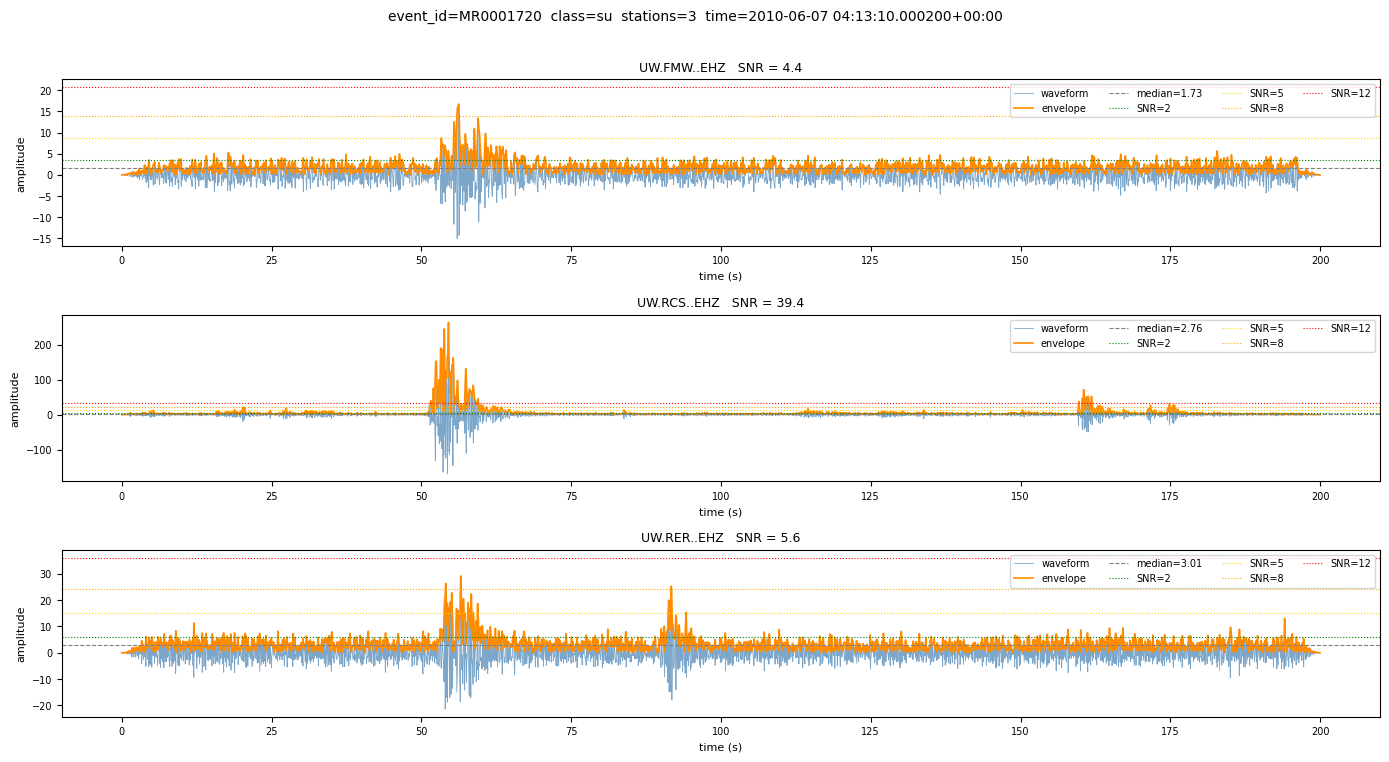


SNR summary:
  UW.FMW..EHZ                          SNR=4.36    passes: {2: True, 5: False, 8: False, 12: False}
  UW.RCS..EHZ                          SNR=39.40   passes: {2: True, 5: True, 8: True, 12: True}
  UW.RER..EHZ                          SNR=5.58    passes: {2: True, 5: True, 8: False, 12: False}


In [10]:
# ── download & plot — run this cell for each event ────────────────────────────
# change EVENT_IDX (0 to NMAX-1) to step through events

EVENT_IDX = 0

row = sampled.iloc[EVENT_IDX]
print(f"Downloading: {row['rounded_start']}  "
      f"class={row['most_common_class']}  stations={row['num_stations']}")

stream = download_traces(row)
print(f"Downloaded {len(stream)} traces")

st = preprocess(stream)
print(f"After preprocessing: {len(st)} traces")

if not st:
    print("No traces survived preprocessing.")
else:
    n_traces = len(st)
    fig, axes = plt.subplots(n_traces, 1,
                              figsize=(14, 2.5 * n_traces),
                              sharex=False)
    if n_traces == 1:
        axes = [axes]

    fig.suptitle(
        f"event_id={row.get('event_id','?')}  class={row['most_common_class']}  "
        f"stations={row['num_stations']}  time={row['rounded_start']}",
        fontsize=10, y=1.01
    )

    threshold_colors = ["green", "gold", "orange", "red"]

    for ax, tr in zip(axes, st):
        times = tr.times()
        data  = tr.data.astype(float)
        x     = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
        env   = np.abs(hilbert(x))
        med   = np.median(env)
        snr   = robust_envelope_snr(tr)

        ax.plot(times, data, color="steelblue", lw=0.6, alpha=0.7, label="waveform")
        ax.plot(times, env,  color="darkorange", lw=1.2, label="envelope")
        ax.axhline(med, color="gray", lw=0.8, ls="--", label=f"median={med:.2f}")

        for thresh, col in zip(SNR_THRESHOLD_RANGE, threshold_colors):
            ax.axhline(med * thresh, color=col, lw=0.8, ls=":",
                       label=f"SNR={thresh}")

        snr_str = f"{snr:.1f}" if np.isfinite(snr) else "nan"
        ax.set_title(f"{tr.id}   SNR = {snr_str}", fontsize=9)
        ax.set_xlabel("time (s)", fontsize=8)
        ax.set_ylabel("amplitude", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, loc="upper right", ncol=4)

    plt.tight_layout()
    plt.show()

    print("\nSNR summary:")
    for tr in st:
        snr = robust_envelope_snr(tr)
        snr_str = f"{snr:.2f}" if np.isfinite(snr) else "nan"
        passes = {thresh: (snr >= thresh if np.isfinite(snr) else False)
                  for thresh in SNR_THRESHOLD_RANGE}
        print(f"  {tr.id:35s}  SNR={snr_str:6s}  passes: {passes}")

In [6]:
row = sampled.iloc[EVENT_IDX]
stations = ast.literal_eval(row["stations"])
print(stations)

['FMW', 'RCS', 'RER']


In [7]:
start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time - SECONDS_BEFORE
t_end   = start_time + SECONDS_AFTER

# try one station manually
sta = stations[0]
for ch in ("BHZ", "HHZ", "EHZ"):
    try:
        st = pnw_client.get_waveforms("*", sta, "*", ch, t_start, t_end)
        print(f"{sta} {ch}: {st}")
    except Exception as e:
        print(f"{sta} {ch}: ERROR — {e}")

FMW BHZ: ERROR — get_waveforms() takes from 1 to 5 positional arguments but 7 were given
FMW HHZ: ERROR — get_waveforms() takes from 1 to 5 positional arguments but 7 were given
FMW EHZ: ERROR — get_waveforms() takes from 1 to 5 positional arguments but 7 were given


In [8]:
help(pnw_client.get_waveforms)

Help on method get_waveforms in module pnwstore.mseed:

get_waveforms(headeronly: 'bool' = False, starttime: 'obspy.UTCDateTime | str | None' = None, endtime: 'obspy.UTCDateTime | str | None' = None, filename: 'str | None' = None, **kwargs: 'Any') method of pnwstore.mseed.WaveformClient instance



In [1]:
"""
locate_events.py
----------------
Locates seismic events from the master catalog (output of build_catalog.py)
using enveloc (XCOR). No minimum station or class purity filters applied.
SNR filtering is the only waveform quality criterion.

Waveform retrieval:
  - pnwstore (WaveformClient) for data up to end of 2022
  - IRIS FDSN for data from 2023 onward

Usage:
    conda activate enveloc
    python locate_events.py --catalog catalog_output/master_catalog.csv \
                            --outfile catalog_output/located_events.csv \
                            --nmax 10          # optional: limit to first N events for testing
"""

import argparse
import ast
import logging
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import hilbert

from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
from obspy.signal.filter import envelope

from pnwstore import WaveformClient

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────

# Waveform download window (seconds) around rounded_start
SECONDS_BEFORE = 0
SECONDS_AFTER  = 200

# Preprocessing parameters
FREQMIN  = 1.0    # bandpass low  (Hz)
FREQMAX  = 8.0    # bandpass high (Hz)
LOWPASS  = 0.2    # envelope smoothing lowpass (Hz)
DT       = 10     # edge trim after taper (seconds each side)
TARGET_FS_WAVEFORM = 50.0
TARGET_FS_ENVELOPE = 5.0
SNR_THRESHOLD      = 5.0   # empirically validated

# Geographic bounding box for FDSN metadata queries (Mount Rainier region)
MINLAT, MAXLAT = 46.0, 49.0
MINLON, MAXLON = -123.0, -120.0

# FDSN client name (metadata always; waveforms post-2022)
FDSN_CLIENT = "IRIS"

# Year boundary: use pnwstore for <= this year, FDSN for > this year
PNWSTORE_END_YEAR = 2022

# Enveloc search grid over the PNW / Mount Rainier region
ENVELOC_GRID = {
    "deps": np.arange(0.1, 1.0, 0.5),
    "lons": np.arange(-123.0, -120.0, 0.05),
    "lats": np.arange(46.0, 49.0, 0.05),
}

# Infrasound and weather channel prefixes to exclude
EXCLUDE_CHANNEL_PREFIXES = (
    "DF",   # infrasound
    "HDF",  # infrasound high-gain
    "LDF",  # infrasound low-freq
    "BDF",  # infrasound broadband
    "EDF",  # infrasound
    "LDO",  # differential pressure
    "LKO",  # tiltmeter
    "LWS",  # wind speed
    "LWD",  # wind direction
    "LRI",  # rainfall
    "LDI",  # lightning
    "VM",   # very long period / tilt
    "LD",   # pressure catch-all
)

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger(__name__)

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def is_excluded_channel(channel: str) -> bool:
    """Return True if the channel matches any excluded prefix."""
    return any(channel.upper().startswith(p) for p in EXCLUDE_CHANNEL_PREFIXES)


def drop_stations_with_gaps(st: Stream, max_total_gap_s: float = 0.0) -> Stream:
    out = Stream()
    for tr_id in sorted(set(tr.id for tr in st)):
        s = st.select(id=tr_id).copy()
        if not s:
            continue
        gaps = s.get_gaps()
        total_gap = sum(float(g[6]) for g in gaps) if gaps else 0.0
        if total_gap > max_total_gap_s:
            log.debug("  Dropped %s (gap %.2f s)", tr_id, total_gap)
            continue
        s.merge(method=1)
        out += s[0]
    return out


def resolve_net_loc_chan(fdsn_client: Client, station: str,
                         t_start: UTCDateTime, t_end: UTCDateTime,
                         loc_preference=("01", "", "--")):
    """
    Query FDSN for network/location/channel for a station in the bounding box.
    Excludes infrasound/weather channels. Returns (net, sta, loc, chan) or None.
    """
    try:
        inv = fdsn_client.get_stations(
            network="*", station=station, channel="*HZ",
            starttime=t_start, endtime=t_end,
            minlatitude=MINLAT, maxlatitude=MAXLAT,
            minlongitude=MINLON, maxlongitude=MAXLON,
            level="channel",
        )
    except Exception:
        return None

    candidates = []
    for net in inv:
        for sta in net:
            for cha in sta:
                if is_excluded_channel(cha.code):
                    continue
                loc = cha.location_code or ""
                candidates.append((net.code, sta.code, loc, cha.code))

    if not candidates:
        return None

    preferred = [c for c in candidates if c[2] in loc_preference]
    pool = preferred if preferred else candidates
    loc_rank = {loc: i for i, loc in enumerate(loc_preference)}
    pool.sort(key=lambda x: (loc_rank.get(x[2], 999), x[3]))
    return pool[0]


def download_waveform_fdsn(fdsn_client: Client, station: str,
                            t_start: UTCDateTime, t_end: UTCDateTime) -> Stream:
    """Download vertical waveform via FDSN (used for post-2022 data)."""
    resolved = resolve_net_loc_chan(fdsn_client, station, t_start, t_end)
    if resolved is None:
        log.debug("  [%s] not found via FDSN", station)
        return Stream()

    net, sta, loc, _ = resolved
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = fdsn_client.get_waveforms(net, sta, loc, ch, t_start, t_end)
            if st:
                log.debug("  FDSN: downloaded %s.%s.%s.%s", net, sta, loc, ch)
                return st
        except Exception:
            pass

    log.debug("  [%s] no vertical channel found via FDSN", station)
    return Stream()


def download_waveform_pnwstore(pnw_client: WaveformClient, station: str,
                                t_start: UTCDateTime, t_end: UTCDateTime) -> Stream:
    """Download vertical waveform via pnwstore (used for <= 2022 data)."""
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = pnw_client.get_waveforms(
                starttime=t_start,
                endtime=t_end,
                station=station,
                channel=ch
            )
            if st:
                log.debug("  pnwstore: downloaded %s %s", station, ch)
                return st
        except Exception:
            pass

    log.debug("  [%s] no vertical channel found via pnwstore", station)
    return Stream()


def download_event_stream(row: pd.Series,
                           fdsn_client: Client,
                           pnw_client: WaveformClient) -> Stream:
    """
    Download waveforms for all stations in a detection row.
    Routes to pnwstore for events in <= PNWSTORE_END_YEAR, FDSN otherwise.
    """
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER
    year    = pd.Timestamp(row["rounded_start"]).year

    try:
        stations = ast.literal_eval(row["stations"])
    except Exception:
        stations = []

    stream = Stream()
    for sta in stations:
        if year <= PNWSTORE_END_YEAR:
            stream += download_waveform_pnwstore(pnw_client, sta, t_start, t_end)
        else:
            stream += download_waveform_fdsn(fdsn_client, sta, t_start, t_end)

    return stream


def robust_envelope_snr(tr, q: float = 0.99, eps: float = 1e-12) -> float:
    x = np.asarray(tr.data, dtype=float)
    if x.size == 0:
        return np.nan
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    env = np.abs(hilbert(x))
    med = np.median(env)
    if not np.isfinite(med) or med < eps:
        return np.nan
    return float(np.quantile(env, q) / med)


def filter_low_snr_traces(st: Stream, threshold: float = SNR_THRESHOLD) -> Stream:
    keep = []
    for tr in st:
        snr = robust_envelope_snr(tr)
        if np.isfinite(snr) and snr >= threshold:
            keep.append(tr)
    dropped = len(st) - len(keep)
    if dropped:
        log.debug("  SNR filter: kept %d / %d traces", len(keep), len(st))
    return Stream(keep)


def attach_coordinates(st_env: Stream, fdsn_client: Client) -> None:
    for tr in st_env:
        try:
            inv = fdsn_client.get_stations(
                network=tr.stats.network,
                station=tr.stats.station,
                location=tr.stats.location,
                channel=tr.stats.channel,
                starttime=tr.stats.starttime,
                endtime=tr.stats.endtime,
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inv[0][0].latitude,
                "longitude": inv[0][0].longitude,
                "elevation": inv[0][0].elevation,
            })
        except Exception as e:
            log.debug("  Could not get coords for %s: %s", tr.id, e)


def preprocess_and_locate(stream: Stream, fdsn_client: Client):
    """
    Full preprocessing pipeline → enveloc location.
    Returns (latitude, longitude, n_traces) or (nan, nan, n) on failure.
    """
    from enveloc.core import XCOR

    if not stream:
        return np.nan, np.nan, 0

    # 1. Drop gappy traces
    stream = drop_stations_with_gaps(stream, max_total_gap_s=0.0)
    if not stream:
        return np.nan, np.nan, 0

    # 2. Bandpass filter
    st_filt = stream.copy()
    st_filt.detrend("demean")
    st_filt.taper(max_percentage=None, max_length=5)
    st_filt.resample(TARGET_FS_WAVEFORM)
    st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX,
                   corners=3, zerophase=True)

    # 3. SNR filter — empirically validated threshold of 5.0
    st_filt = filter_low_snr_traces(st_filt, threshold=SNR_THRESHOLD)
    if not st_filt:
        log.debug("  No traces survived SNR filter.")
        return np.nan, np.nan, 0

    # 4. Build envelopes
    st_env = st_filt.copy()
    for tr in st_env:
        if tr.stats.npts % 2 == 1:
            tr.trim(tr.stats.starttime,
                    tr.stats.endtime + 1.0 / tr.stats.sampling_rate,
                    pad=True, fill_value=0)
        tr.data = envelope(tr.data)
        tr.resample(TARGET_FS_ENVELOPE)

    st_env.filter("lowpass", freq=LOWPASS)

    # 5. Trim taper edges
    t1 = st_filt[0].stats.starttime + DT
    t2 = st_filt[0].stats.endtime   - DT
    st_filt.trim(t1, t2)
    st_env.trim(t1, t2)

    # 6. Attach coordinates
    attach_coordinates(st_env, fdsn_client)

    st_env_ok = Stream([tr for tr in st_env
                        if hasattr(tr.stats, "coordinates")])
    if len(st_env_ok) < 3:
        log.debug("  Too few traces with coordinates (%d).", len(st_env_ok))
        return np.nan, np.nan, len(st_env_ok)

    n_traces = len(st_env_ok)

    # 7. Run enveloc
    try:
        XC = XCOR(st_env_ok, plot=False, interact=False)
        loc = XC.locate()
        lat = float(loc.latitude)  if loc.latitude  is not None else np.nan
        lon = float(loc.longitude) if loc.longitude is not None else np.nan
        return lat, lon, n_traces
    except Exception as e:
        log.debug("  enveloc failed: %s", e)
        return np.nan, np.nan, n_traces


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description="Locate events from master catalog")
    parser.add_argument(
        "--catalog",
        default="catalog_output/master_catalog.csv",
        help="Path to master_catalog.csv from build_catalog.py"
    )
    parser.add_argument(
        "--outfile",
        default="catalog_output/located_events.csv",
        help="Output CSV path"
    )
    parser.add_argument(
        "--nmax",
        type=int,
        default=None,
        help="Process only the first N events (useful for testing)"
    )
    parser.add_argument(
        "--fdsn_client",
        default=FDSN_CLIENT,
        help="FDSN client name (default: IRIS)"
    )
    args = parser.parse_args()

    # ── Load catalog ──────────────────────────────────────────────────────
    log.info("Loading catalog: %s", args.catalog)
    catalog = pd.read_csv(args.catalog)
    log.info("Total events in catalog: %d", len(catalog))

    if args.nmax is not None:
        catalog = catalog.head(args.nmax)
        log.info("Limiting to first %d events (--nmax)", args.nmax)

    # ── Clients ───────────────────────────────────────────────────────────
    fdsn_client = Client(args.fdsn_client)
    pnw_client  = WaveformClient()

    # ── Prepare output columns ────────────────────────────────────────────
    catalog["enveloc_latitude"]  = np.nan
    catalog["enveloc_longitude"] = np.nan
    catalog["n_traces_used"]     = np.nan
    catalog["location_status"]   = ""

    total   = len(catalog)
    located = 0
    failed  = 0

    for idx, row in catalog.iterrows():
        event_label = (
            f"[{idx+1}/{total}] event_id={row.get('event_id', idx)} "
            f"@ {row['rounded_start']}  class={row['most_common_class']}  "
            f"stations={row['num_stations']}"
        )
        log.info("Processing %s", event_label)

        try:
            stream = download_event_stream(row, fdsn_client, pnw_client)

            if not stream:
                log.warning("  No waveforms downloaded — skipping.")
                catalog.at[idx, "location_status"] = "no_waveforms"
                failed += 1
                continue

            lat, lon, n_tr = preprocess_and_locate(stream, fdsn_client)
            catalog.at[idx, "n_traces_used"] = n_tr

            if np.isfinite(lat) and np.isfinite(lon):
                catalog.at[idx, "enveloc_latitude"]  = lat
                catalog.at[idx, "enveloc_longitude"] = lon
                catalog.at[idx, "location_status"]   = "located"
                located += 1
                log.info("  ✓  lat=%.4f  lon=%.4f  (%d traces)", lat, lon, n_tr)
            else:
                catalog.at[idx, "location_status"] = "enveloc_failed"
                failed += 1
                log.warning("  ✗  enveloc returned nan  (%d traces)", n_tr)

        except KeyboardInterrupt:
            log.warning("Interrupted — saving partial results.")
            break
        except Exception:
            log.error("  Unexpected error:\n%s", traceback.format_exc())
            catalog.at[idx, "location_status"] = "error"
            failed += 1

    # ── Save output ───────────────────────────────────────────────────────
    out_cols = [
        "event_id", "cluster_id", "rounded_start", "year", "month",
        "num_stations", "most_common_class", "vote_margin",
        "mean_max", "mean_prob", "mean_auc_per_station",
        "high_confidence", "low_confidence", "ambiguous_class",
        "enveloc_latitude", "enveloc_longitude",
        "n_traces_used", "location_status",
    ]
    out_cols = [c for c in out_cols if c in catalog.columns]

    Path(args.outfile).parent.mkdir(parents=True, exist_ok=True)
    catalog[out_cols].to_csv(args.outfile, index=False)

    log.info("─" * 60)
    log.info("Done.  Located: %d / %d  |  Failed/skipped: %d", located, total, failed)
    log.info("Output saved to: %s", args.outfile)


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--catalog CATALOG] [--outfile OUTFILE]
                             [--nmax NMAX] [--fdsn_client FDSN_CLIENT]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/ak287/.local/share/jupyter/runtime/kernel-73096b2e-0b2d-48e3-9e8b-5c058a812590.json


SystemExit: 2

/home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
fdsn_client = Client('iris')

In [8]:
import time
import ast
import numpy as np
import pandas as pd
from scipy.signal import hilbert

from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
from obspy.signal.filter import envelope
from enveloc.core import XCOR
from pnwstore import WaveformClient

# ── clients ───────────────────────────────────────────────────────────────────
fdsn_client = Client("IRIS")
pnw_client  = WaveformClient()

# ── params ────────────────────────────────────────────────────────────────────
CATALOG_PATH       = "../src/catalog_output/master_catalog.csv"
SECONDS_BEFORE     = 0
SECONDS_AFTER      = 200
FREQMIN            = 1.0
FREQMAX            = 8.0
LOWPASS            = 0.2
DT                 = 10
TARGET_FS_WAVEFORM = 50.0
TARGET_FS_ENVELOPE = 5.0
SNR_THRESHOLD      = 5.0
PNWSTORE_END_YEAR  = 2022
MINLAT, MAXLAT     = 46.0, 49.0
MINLON, MAXLON     = -123.0, -120.0

EXCLUDE_CHANNEL_PREFIXES = (
    "DF", "HDF", "LDF", "BDF", "EDF", "LDO", "LKO",
    "LWS", "LWD", "LRI", "LDI", "VM", "LD",
)

catalog = pd.read_csv(CATALOG_PATH)

# ── helpers ───────────────────────────────────────────────────────────────────

def is_excluded_channel(channel):
    return any(channel.upper().startswith(p) for p in EXCLUDE_CHANNEL_PREFIXES)

def drop_stations_with_gaps(st, max_total_gap_s=0.0):
    out = Stream()
    for tr_id in sorted(set(tr.id for tr in st)):
        s = st.select(id=tr_id).copy()
        if not s:
            continue
        gaps = s.get_gaps()
        total_gap = sum(float(g[6]) for g in gaps) if gaps else 0.0
        if total_gap > max_total_gap_s:
            continue
        s.merge(method=1)
        out += s[0]
    return out

def robust_envelope_snr(tr, q=0.99, eps=1e-12):
    x = np.nan_to_num(np.asarray(tr.data, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if x.size == 0:
        return np.nan
    env = np.abs(hilbert(x))
    med = np.median(env)
    if not np.isfinite(med) or med < eps:
        return np.nan
    return float(np.quantile(env, q) / med)

def filter_low_snr_traces(st, threshold=SNR_THRESHOLD):
    return Stream([tr for tr in st
                   if np.isfinite(robust_envelope_snr(tr))
                   and robust_envelope_snr(tr) >= threshold])

def resolve_net_loc_chan(fdsn_client, station, t_start, t_end,
                         loc_preference=("01", "", "--")):
    try:
        inv = fdsn_client.get_stations(
            network="*", station=station, channel="*HZ",
            starttime=t_start, endtime=t_end,
            minlatitude=MINLAT, maxlatitude=MAXLAT,
            minlongitude=MINLON, maxlongitude=MAXLON,
            level="channel",
        )
    except Exception:
        return None
    candidates = []
    for net in inv:
        for sta in net:
            for cha in sta:
                if is_excluded_channel(cha.code):
                    continue
                loc = cha.location_code or ""
                candidates.append((net.code, sta.code, loc, cha.code))
    if not candidates:
        return None
    preferred = [c for c in candidates if c[2] in loc_preference]
    pool = preferred if preferred else candidates
    loc_rank = {loc: i for i, loc in enumerate(loc_preference)}
    pool.sort(key=lambda x: (loc_rank.get(x[2], 999), x[3]))
    return pool[0]

def download_waveform_fdsn(fdsn_client, station, t_start, t_end):
    resolved = resolve_net_loc_chan(fdsn_client, station, t_start, t_end)
    if resolved is None:
        return Stream()
    net, sta, loc, _ = resolved
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = fdsn_client.get_waveforms(net, sta, loc, ch, t_start, t_end)
            if st:
                return st
        except Exception:
            pass
    return Stream()

def download_waveform_pnwstore(pnw_client, station, t_start, t_end):
    for ch in ("BHZ", "HHZ", "EHZ"):
        if is_excluded_channel(ch):
            continue
        try:
            st = pnw_client.get_waveforms(
                starttime=t_start, endtime=t_end,
                station=station, channel=ch
            )
            if st:
                return st
        except Exception:
            pass
    return Stream()

def download_event_stream(row, fdsn_client, pnw_client):
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER
    year    = pd.Timestamp(row["rounded_start"]).year
    try:
        stations = ast.literal_eval(row["stations"])
    except Exception:
        stations = []
    stream = Stream()
    for sta in stations:
        if year <= PNWSTORE_END_YEAR:
            stream += download_waveform_pnwstore(pnw_client, sta, t_start, t_end)
        else:
            stream += download_waveform_fdsn(fdsn_client, sta, t_start, t_end)
    return stream

def attach_coordinates(st_env, fdsn_client):
    for tr in st_env:
        try:
            inv = fdsn_client.get_stations(
                network=tr.stats.network,
                station=tr.stats.station,
                location=tr.stats.location,
                channel=tr.stats.channel,
                starttime=tr.stats.starttime,
                endtime=tr.stats.endtime,
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inv[0][0].latitude,
                "longitude": inv[0][0].longitude,
                "elevation": inv[0][0].elevation,
            })
        except Exception:
            pass

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


In [22]:
row

cluster_id                                                     109
rounded_start                     2010-01-16 04:12:20.000200+00:00
num_stations                                                     6
stations                ['FMW', 'LO2', 'LON', 'RCM', 'RCS', 'RER']
all_classes                   ['su', 'su', 'su', 'su', 'px', 'px']
most_common_class                                               su
mean_auc                                                  9.088481
mean_max                                                  0.684717
mean_prob                                                 0.366572
file_date                                               2010-01-16
date                                                    2010-01-16
year                                                          2010
month                                                            1
hour                                                             4
doy                                                           

In [21]:
# ── diagnostic timing cell ────────────────────────────────────────────────────

row = catalog[catalog["num_stations"] > 5].iloc[0]
start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time - SECONDS_BEFORE
t_end   = start_time + SECONDS_AFTER

# time the download
t0 = time.time()
stream = download_event_stream(row, fdsn_client, pnw_client)
print(f"Download     : {time.time()-t0:.2f}s  ({len(stream)} traces)")

# time preprocessing
t0 = time.time()
stream = drop_stations_with_gaps(stream)
st_filt = stream.copy()
st_filt.detrend("demean")
st_filt.taper(max_percentage=None, max_length=5)
st_filt.resample(TARGET_FS_WAVEFORM)
st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=3, zerophase=True)
st_filt = filter_low_snr_traces(st_filt)
print(f"Preprocessing: {time.time()-t0:.2f}s  ({len(st_filt)} traces after SNR)")

# time coordinate attachment
t0 = time.time()
st_env = st_filt.copy()
for tr in st_env:
    if tr.stats.npts % 2 == 1:
        tr.trim(tr.stats.starttime, tr.stats.endtime + 1.0/tr.stats.sampling_rate,
                pad=True, fill_value=0)
    tr.data = envelope(tr.data)
    tr.resample(TARGET_FS_ENVELOPE)
st_env.filter("lowpass", freq=LOWPASS)
attach_coordinates(st_env, fdsn_client)
print(f"Coords attach: {time.time()-t0:.2f}s")

# time enveloc
t0 = time.time()
st_env_ok = Stream([tr for tr in st_env if hasattr(tr.stats, "coordinates")])
if len(st_env_ok) >= 3:
    XC = XCOR(st_env_ok, plot=False, interact=False)
    loc = XC.locate()
    print(f"Enveloc      : {time.time()-t0:.2f}s")
else:
    print(f"Enveloc      : skipped (only {len(st_env_ok)} traces with coords)")

Download     : 7.88s  (6 traces)
Preprocessing: 0.03s  (3 traces after SNR)
Coords attach: 0.03s
Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2010.01.16 04:12:20  --  2010.01.16 04:15:39
WARNING FROM XC_locate: too many traces with no data
Enveloc      : 3.10s


In [17]:
from obspy import UTCDateTime
from pnwstore import StationClient

USERNAME = 'ak287'
PASSWORD = 'uwquake'
client = StationClient(USERNAME, PASSWORD)
client.query(network = "UW", channel = "EH?",
             mintime = UTCDateTime("2010-01-15"),
             maxtime = UTCDateTime("2000-01-16"))

ProgrammingError: 1045 (28000): Access denied for user 'ak287'@'cascadia' (using password: YES)

In [18]:
# test one event and see which client is serving each station
row = catalog[catalog["year"] <= 2022].iloc[0]

start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time - SECONDS_BEFORE
t_end   = start_time + SECONDS_AFTER
year    = pd.Timestamp(row["rounded_start"]).year

try:
    stations = ast.literal_eval(row["stations"])
except Exception:
    stations = []

print(f"Event: {row['rounded_start']}  year={year}  stations={stations}")
print(f"Expected client: {'pnwstore' if year <= PNWSTORE_END_YEAR else 'FDSN'}\n")

for sta in stations:
    for ch in ("BHZ", "HHZ", "EHZ"):
        t0 = time.time()
        try:
            if year <= PNWSTORE_END_YEAR:
                st = pnw_client.get_waveforms(
                    starttime=t_start, endtime=t_end,
                    station=sta, channel=ch
                )
                client_used = "pnwstore"
            else:
                st = fdsn_client.get_waveforms("*", sta, "*", ch, t_start, t_end)
                client_used = "FDSN"

            elapsed = time.time() - t0
            if st:
                print(f"  {sta} {ch}: ✓  {client_used}  {elapsed:.2f}s  {st[0].stats.sampling_rate}Hz  {len(st[0].data)} samples")
                break
            else:
                print(f"  {sta} {ch}: empty  {client_used}  {elapsed:.2f}s")
        except Exception as e:
            elapsed = time.time() - t0
            print(f"  {sta} {ch}: ERROR  {elapsed:.2f}s  — {e}")

Event: 2010-01-01 00:00:50.000400+00:00  year=2010  stations=['FMW', 'RCM', 'RER', 'RVC']
Expected client: pnwstore

  FMW BHZ: empty  pnwstore  0.48s
  FMW HHZ: empty  pnwstore  0.48s
  FMW EHZ: ✓  pnwstore  0.51s  100.0Hz  20001 samples
  RCM BHZ: empty  pnwstore  0.48s
  RCM HHZ: empty  pnwstore  0.48s
  RCM EHZ: ✓  pnwstore  0.50s  100.0Hz  20001 samples
  RER BHZ: empty  pnwstore  0.48s
  RER HHZ: empty  pnwstore  0.48s
  RER EHZ: ✓  pnwstore  0.50s  100.0Hz  20001 samples
  RVC BHZ: empty  pnwstore  0.49s
  RVC HHZ: empty  pnwstore  0.49s
  RVC EHZ: ✓  pnwstore  0.52s  100.0Hz  20001 samples


In [20]:
# test one event and see which client is serving each station
row = catalog[catalog["year"] == 2024].iloc[0]

start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time - SECONDS_BEFORE
t_end   = start_time + SECONDS_AFTER
year    = pd.Timestamp(row["rounded_start"]).year

try:
    stations = ast.literal_eval(row["stations"])
except Exception:
    stations = []

print(f"Event: {row['rounded_start']}  year={year}  stations={stations}")
print(f"Expected client: {'pnwstore' if year <= PNWSTORE_END_YEAR else 'FDSN'}\n")

for sta in stations:
    for ch in ("BHZ", "HHZ", "EHZ"):
        t0 = time.time()
        try:
            if year <= PNWSTORE_END_YEAR:
                st = pnw_client.get_waveforms(
                    starttime=t_start, endtime=t_end,
                    station=sta, channel=ch
                )
                client_used = "pnwstore"
            else:
                st = fdsn_client.get_waveforms("*", sta, "*", ch, t_start, t_end)
                client_used = "FDSN"

            elapsed = time.time() - t0
            if st:
                print(f"  {sta} {ch}: ✓  {client_used}  {elapsed:.2f}s  {st[0].stats.sampling_rate}Hz  {len(st[0].data)} samples")
                break
            else:
                print(f"  {sta} {ch}: empty  {client_used}  {elapsed:.2f}s")
        except Exception as e:
            elapsed = time.time() - t0
            print(f"  {sta} {ch}: ERROR  {elapsed:.2f}s  — {e}")

Event: 2024-01-01 00:00:50+00:00  year=2024  stations=['GSM', 'RCM', 'WPEQ']
Expected client: FDSN

  GSM BHZ: ERROR  0.12s  — No data available for request.
HTTP Status code: 204
Detailed response of server:


  GSM HHZ: ERROR  0.33s  — No data available for request.
HTTP Status code: 204
Detailed response of server:


  GSM EHZ: ✓  FDSN  0.28s  100.0Hz  20001 samples
  RCM BHZ: ERROR  0.11s  — No data available for request.
HTTP Status code: 204
Detailed response of server:


  RCM HHZ: ✓  FDSN  0.44s  100.0Hz  20001 samples
  WPEQ BHZ: ERROR  0.14s  — No data available for request.
HTTP Status code: 204
Detailed response of server:


  WPEQ HHZ: ✓  FDSN  0.29s  100.0Hz  20001 samples


## Comparing the speed of Sequential v/s Parallel downloading

In [35]:
# ── Cell 1: time sequential downloads for 10 events ──────────────────────────
import time

N_TEST = 20
sample = catalog.dropna(subset=["stations"]).sample(N_TEST, random_state=42).reset_index(drop=True)

print("=== SEQUENTIAL ===")
sequential_times = []

for i, row in sample.iterrows():
    t0 = time.time()
    stream = download_event_stream(row, fdsn_client, pnw_client)
    elapsed = time.time() - t0
    sequential_times.append(elapsed)
    print(f"  [{i+1}/{N_TEST}]  {row['rounded_start']}  "
          f"year={row['year']}  {len(stream)} traces  {elapsed:.2f}s")

print(f"\n  Total   : {sum(sequential_times):.1f}s")
print(f"  Mean    : {sum(sequential_times)/len(sequential_times):.1f}s/event")

=== SEQUENTIAL ===
  [1/20]  2019-12-11 05:54:00.010000+00:00  year=2019  5 traces  5.63s
  [2/20]  2025-01-07 07:29:30+00:00  year=2025  4 traces  1.88s
  [3/20]  2023-09-01 07:36:10+00:00  year=2023  9 traces  3.76s
  [4/20]  2015-08-27 23:27:20.015000+00:00  year=2015  3 traces  4.35s
  [5/20]  2022-01-03 21:19:30+00:00  year=2022  7 traces  10.32s
  [6/20]  2025-08-09 19:12:50+00:00  year=2025  5 traces  1.79s
  [7/20]  2019-09-06 07:33:50.000767+00:00  year=2019  4 traces  3.16s
  [8/20]  2012-02-15 11:34:30+00:00  year=2012  3 traces  4.44s
  [9/20]  2012-09-17 21:52:10.649900+00:00  year=2012  3 traces  3.18s
  [10/20]  2023-03-02 16:31:00+00:00  year=2023  3 traces  2.42s
  [11/20]  2022-10-07 08:40:10+00:00  year=2022  5 traces  10.39s
  [12/20]  2025-09-18 19:09:50+00:00  year=2025  10 traces  3.36s
  [13/20]  2026-02-09 03:56:40+00:00  year=2026  6 traces  2.25s
  [14/20]  2022-06-01 20:32:30+00:00  year=2022  3 traces  9.02s
  [15/20]  2024-02-17 03:02:20+00:00  year=2024  

In [33]:
# ── Cell 2: time parallel downloads for the same 10 events ───────────────────
from concurrent.futures import ThreadPoolExecutor, as_completed
    
    
def download_single_station(args):
    sta, year, t_start, t_end = args
    if year <= PNWSTORE_END_YEAR:
        # create a fresh client per thread — pnwstore uses SQLite
        # which cannot be shared across threads
        thread_pnw_client = WaveformClient()
        return download_waveform_pnwstore(thread_pnw_client, sta, t_start, t_end)
    else:
        return download_waveform_fdsn(fdsn_client, sta, t_start, t_end)
    

def download_event_stream_parallel(row, n_workers= 32):
    start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
    t_start = start_time - SECONDS_BEFORE
    t_end   = start_time + SECONDS_AFTER
    year    = pd.Timestamp(row["rounded_start"]).year

    try:
        stations = ast.literal_eval(row["stations"])
    except Exception:
        stations = []

    if not stations:
        return Stream()

    tasks = [(sta, year, t_start, t_end) for sta in stations]
    stream = Stream()

    with ThreadPoolExecutor(max_workers=min(n_workers, len(tasks))) as executor:
        futures = {executor.submit(download_single_station, t): t[0] for t in tasks}
        for future in as_completed(futures):
            try:
                st = future.result()
                if st:
                    stream += st
            except Exception as e:
                print(f"    station error: {e}")

    return stream

print("=== PARALLEL (8 workers) ===")
parallel_times = []

for i, row in sample.iterrows():
    t0 = time.time()
    stream = download_event_stream_parallel(row, n_workers=8)
    elapsed = time.time() - t0
    parallel_times.append(elapsed)
    print(f"  [{i+1}/{N_TEST}]  {row['rounded_start']}  "
          f"year={row['year']}  {len(stream)} traces  {elapsed:.2f}s")

print(f"\n  Total   : {sum(parallel_times):.1f}s")
print(f"  Mean    : {sum(parallel_times)/len(parallel_times):.1f}s/event")

# ── summary ───────────────────────────────────────────────────────────────────
speedup = sum(sequential_times) / sum(parallel_times)
print(f"\n=== SPEEDUP ===")
print(f"  Sequential total : {sum(sequential_times):.1f}s")
print(f"  Parallel total   : {sum(parallel_times):.1f}s")
print(f"  Speedup          : {speedup:.1f}x")

total_events = len(catalog)
for label, mean_t in [("sequential", sum(sequential_times)/len(sequential_times)),
                       ("parallel",   sum(parallel_times)/len(parallel_times))]:
    secs = mean_t * total_events
    h, m = int(secs // 3600), int((secs % 3600) // 60)
    print(f"  Extrapolated ({label}): {h}h {m}m for {total_events:,} events")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


=== PARALLEL (8 workers) ===
  [1/10]  2019-12-11 05:54:00.010000+00:00  year=2019  5 traces  2.61s
  [2/10]  2025-01-07 07:29:30+00:00  year=2025  4 traces  0.64s


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  [3/10]  2023-09-01 07:36:10+00:00  year=2023  9 traces  0.99s


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


...

  [6/10]  2025-08-09 19:12:50+00:00  year=2025  5 traces  1.52s


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  [7/10]  2019-09-06 07:33:50.000767+00:00  year=2019  4 traces  2.29s


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  [8/10]  2012-02-15 11:34:30+00:00  year=2012  3 traces  2.65s
  [9/10]  2012-09-17 21:52:10.649900+00:00  year=2012  3 traces  2.13s
  [10/10]  2023-03-02 16:31:00+00:00  year=2023  3 traces  0.60s

  Total   : 19.5s
  Mean    : 2.0s/event

=== SPEEDUP ===
  Sequential total : 38.8s
  Parallel total   : 19.5s
  Speedup          : 2.0x
  Extrapolated (sequential): 707h 28m for 656,973 events
  Extrapolated (parallel): 356h 26m for 656,973 events


In [29]:
# test if pnwstore is thread-safe by calling it from two threads simultaneously
from concurrent.futures import ThreadPoolExecutor

row = catalog[catalog["year"] == 2022].iloc[0]
start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time
t_end   = start_time + 200
stations = ast.literal_eval(row["stations"])

print(f"Testing with {len(stations)} stations: {stations}")

def fetch(sta):
    try:
        st = pnw_client.get_waveforms(starttime=t_start, endtime=t_end,
                                       station=sta, channel="BHZ")
        return sta, len(st), None
    except Exception as e:
        return sta, 0, str(e)

# sequential
print("\n--- Sequential ---")
for sta in stations:
    sta, n, err = fetch(sta)
    print(f"  {sta}: {n} traces  {err or ''}")

# parallel
print("\n--- Parallel (threads) ---")
with ThreadPoolExecutor(max_workers=8) as ex:
    for sta, n, err in ex.map(fetch, stations):
        print(f"  {sta}: {n} traces  {err or ''}")

Testing with 3 stations: ['PANH', 'PARA', 'STAR']

--- Sequential ---
  PANH: 1 traces  
  PARA: 1 traces  
  STAR: 0 traces  

--- Parallel (threads) ---
  PANH: 0 traces  SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139822081438720 and this is thread id 139816611661568.
  PARA: 0 traces  SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139822081438720 and this is thread id 139816611661568.
  STAR: 0 traces  SQLite objects created in a thread can only be used in that same thread. The object was created in thread id 139822081438720 and this is thread id 139816611661568.


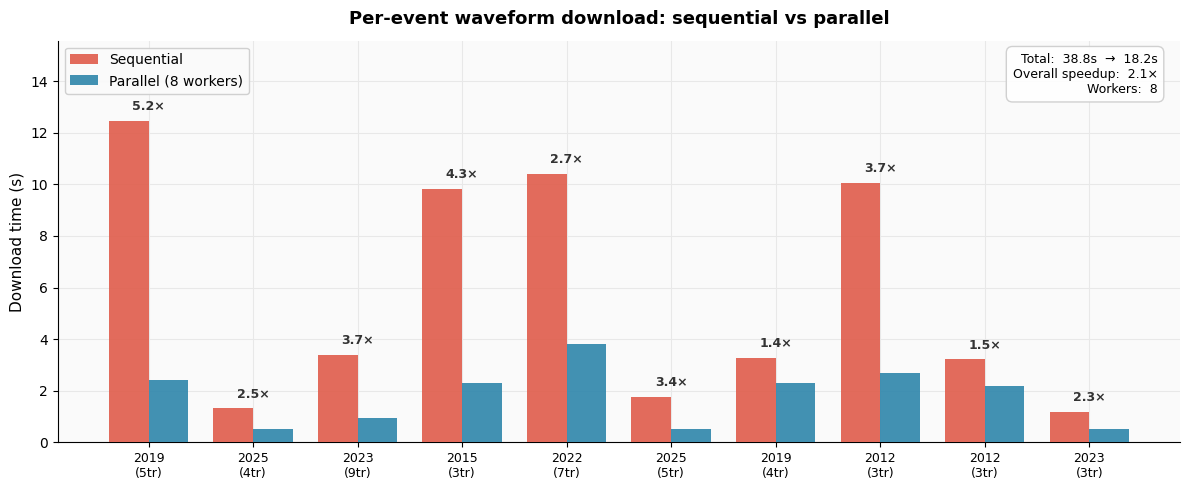

Saved fig1_per_event_timing.png


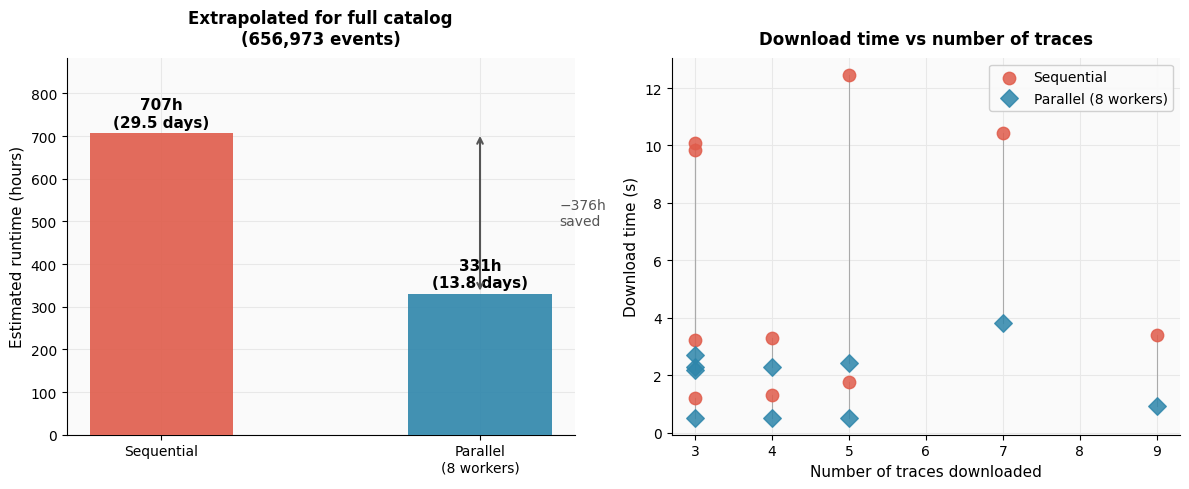

Saved fig2_extrapolation_and_scatter.png


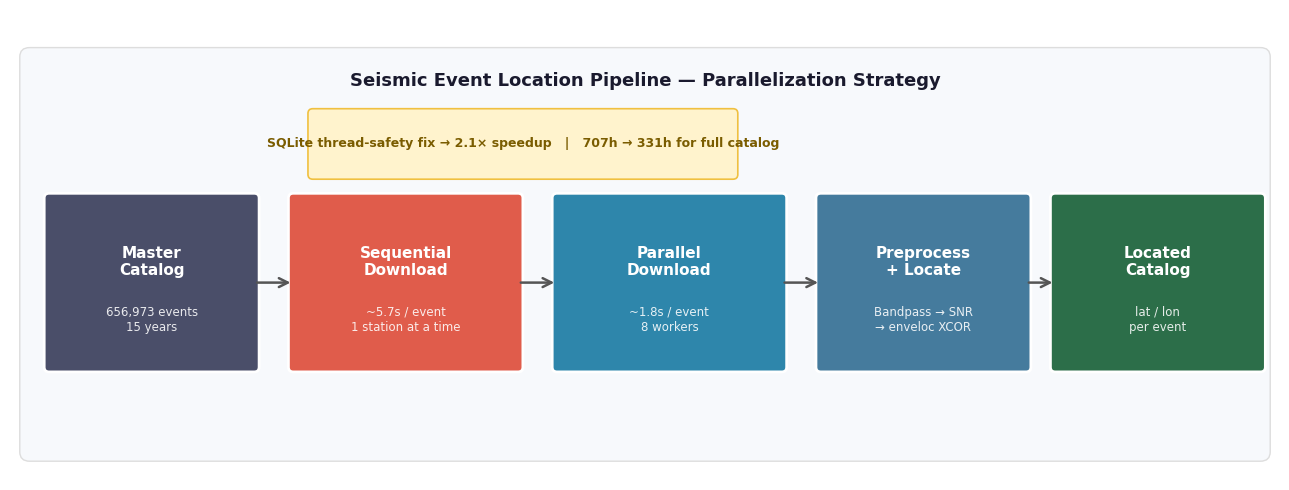

Saved fig3_pipeline_overview.png


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── data from your timing runs ────────────────────────────────────────────────
events = [
    {"time": "2019-12-11", "year": 2019, "traces": 5,  "seq": 12.46, "par": 2.41},
    {"time": "2025-01-07", "year": 2025, "traces": 4,  "seq": 1.31,  "par": 0.52},
    {"time": "2023-09-01", "year": 2023, "traces": 9,  "seq": 3.40,  "par": 0.93},
    {"time": "2015-08-27", "year": 2015, "traces": 3,  "seq": 9.83,  "par": 2.29},
    {"time": "2022-01-03", "year": 2022, "traces": 7,  "seq": 10.42, "par": 3.82},
    {"time": "2025-08-09", "year": 2025, "traces": 5,  "seq": 1.76,  "par": 0.52},
    {"time": "2019-09-06", "year": 2019, "traces": 4,  "seq": 3.28,  "par": 2.29},
    {"time": "2012-02-15", "year": 2012, "traces": 3,  "seq": 10.07, "par": 2.70},
    {"time": "2012-09-17", "year": 2012, "traces": 3,  "seq": 3.22,  "par": 2.17},
    {"time": "2023-03-02", "year": 2023, "traces": 3,  "seq": 1.19,  "par": 0.52},
]

seq_times  = [e["seq"]    for e in events]
par_times  = [e["par"]    for e in events]
years      = [e["year"]   for e in events]
traces     = [e["traces"] for e in events]
labels     = [f"{e['year']}\n({e['traces']}tr)" for e in events]

seq_total  = 38.8
par_total  = 18.2
speedup    = seq_total / par_total
seq_extrap = 707   # hours
par_extrap = 331   # hours
n_events   = 656_973
n_workers  = 8

# ── style ─────────────────────────────────────────────────────────────────────
SEQ_COLOR  = "#E05C4B"   # warm red
PAR_COLOR  = "#2E86AB"   # teal blue
GRID_COLOR = "#E8E8E8"
BG_COLOR   = "#FAFAFA"

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       GRID_COLOR,
    "grid.linewidth":   0.8,
    "axes.facecolor":   BG_COLOR,
    "figure.facecolor": "white",
})

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 — Per-event download time: sequential vs parallel
# ─────────────────────────────────────────────────────────────────────────────
fig1, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(events))
width  = 0.38

bars_seq = ax.bar(x - width/2, seq_times, width, color=SEQ_COLOR,
                  alpha=0.9, label="Sequential", zorder=3)
bars_par = ax.bar(x + width/2, par_times, width, color=PAR_COLOR,
                  alpha=0.9, label=f"Parallel ({n_workers} workers)", zorder=3)

# speedup annotation above each pair
for i, (s, p) in enumerate(zip(seq_times, par_times)):
    if p > 0:
        su = s / p
        ax.text(x[i], max(s, p) + 0.3, f"{su:.1f}×",
                ha="center", va="bottom", fontsize=9,
                color="#333333", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Download time (s)", fontsize=11)
ax.set_title("Per-event waveform download: sequential vs parallel",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(0, max(seq_times) * 1.25)

# summary box
summary = (f"Total:  {seq_total}s  →  {par_total}s\n"
           f"Overall speedup:  {speedup:.1f}×\n"
           f"Workers:  {n_workers}")
ax.text(0.98, 0.97, summary, transform=ax.transAxes,
        fontsize=9, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.9))

plt.tight_layout()
plt.savefig("fig1_per_event_timing.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig1_per_event_timing.png")


# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 — Extrapolated runtime for full catalog
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── left: bar chart of extrapolated hours ─────────────────────────────────
ax2 = axes[0]
methods = ["Sequential", f"Parallel\n({n_workers} workers)"]
hours   = [seq_extrap, par_extrap]
colors  = [SEQ_COLOR, PAR_COLOR]

bars = ax2.bar(methods, hours, color=colors, alpha=0.9,
               width=0.45, zorder=3)

for bar, h in zip(bars, hours):
    days = h / 24
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 8,
             f"{h}h\n({days:.1f} days)",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.set_ylabel("Estimated runtime (hours)", fontsize=11)
ax2.set_title(f"Extrapolated for full catalog\n({n_events:,} events)",
              fontsize=12, fontweight="bold", pad=10)
ax2.set_ylim(0, seq_extrap * 1.25)

# time saved annotation
saved = seq_extrap - par_extrap
ax2.annotate("", xy=(1, par_extrap), xytext=(1, seq_extrap),
             arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.5))
ax2.text(1.25, (seq_extrap + par_extrap) / 2,
         f"−{saved}h\nsaved",
         ha="left", va="center", fontsize=10, color="#555555")

# ── right: scatter — traces vs download time colored by method ───────────
ax3 = axes[1]
ax3.scatter(traces, seq_times, color=SEQ_COLOR, s=80, alpha=0.85,
            label="Sequential", zorder=3)
ax3.scatter(traces, par_times, color=PAR_COLOR, s=80, alpha=0.85,
            marker="D", label=f"Parallel ({n_workers} workers)", zorder=3)

# connect pairs with a thin line
for t, s, p in zip(traces, seq_times, par_times):
    ax3.plot([t, t], [s, p], color="#AAAAAA", lw=0.8, zorder=2)

ax3.set_xlabel("Number of traces downloaded", fontsize=11)
ax3.set_ylabel("Download time (s)", fontsize=11)
ax3.set_title("Download time vs number of traces",
              fontsize=12, fontweight="bold", pad=10)
ax3.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("fig2_extrapolation_and_scatter.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig2_extrapolation_and_scatter.png")


# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 — Pipeline overview (slide-friendly summary figure)
# ─────────────────────────────────────────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5)
ax.axis("off")
ax.set_facecolor("white")
fig3.patch.set_facecolor("white")

def draw_box(ax, x, y, w, h, color, title, subtitle, title_color="white"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="white", linewidth=2, zorder=3))
    ax.text(x + w/2, y + h*0.62, title,
            ha="center", va="center", fontsize=11, fontweight="bold",
            color=title_color, zorder=4)
    ax.text(x + w/2, y + h*0.28, subtitle,
            ha="center", va="center", fontsize=8.5,
            color=title_color, alpha=0.88, zorder=4)

def draw_arrow(ax, x1, x2, y):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", color="#555555",
                                lw=1.8, mutation_scale=16))

# problem statement box (dark bg)
ax.add_patch(mpatches.FancyBboxPatch(
    (0.2, 0.3), 12.6, 4.2, boxstyle="round,pad=0.1",
    facecolor="#F7F9FC", edgecolor="#DDDDDD", linewidth=1, zorder=1))

# title
ax.text(6.5, 4.25, "Seismic Event Location Pipeline — Parallelization Strategy",
        ha="center", va="center", fontsize=13, fontweight="bold", color="#1A1A2E")

# pipeline boxes
box_data = [
    (0.4,  1.2, 2.1, 1.8, "#4A4E69", "Master\nCatalog",    "656,973 events\n15 years"),
    (2.9,  1.2, 2.3, 1.8, "#E05C4B", "Sequential\nDownload","~5.7s / event\n1 station at a time"),
    (5.6,  1.2, 2.3, 1.8, "#2E86AB", "Parallel\nDownload",  f"~1.8s / event\n{n_workers} workers"),
    (8.3,  1.2, 2.1, 1.8, "#457B9D", "Preprocess\n+ Locate","Bandpass → SNR\n→ enveloc XCOR"),
    (10.7, 1.2, 2.1, 1.8, "#2C6E49", "Located\nCatalog",    "lat / lon\nper event"),
]

for (x, y, w, h, col, title, sub) in box_data:
    draw_box(ax, x, y, w, h, col, title, sub)

# arrows between boxes
arrow_ys = [(2.5,  2.9,  2.1),
            (5.2,  5.6,  2.1),
            (7.9,  8.3,  2.1),
            (10.4, 10.7, 2.1)]
for x1, x2, y in arrow_ys:
    draw_arrow(ax, x1, x2, y)

# speedup callout
ax.add_patch(mpatches.FancyBboxPatch(
    (3.1, 3.25), 4.3, 0.65, boxstyle="round,pad=0.05",
    facecolor="#FFF3CD", edgecolor="#F0C040", linewidth=1.2, zorder=3))
ax.text(5.25, 3.58,
        f"SQLite thread-safety fix → {speedup:.1f}× speedup   |   "
        f"{seq_extrap}h → {par_extrap}h for full catalog",
        ha="center", va="center", fontsize=9, color="#7A5C00",
        fontweight="bold", zorder=4)

plt.tight_layout()
plt.savefig("fig3_pipeline_overview.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved fig3_pipeline_overview.png")

In [37]:
# test directly — does pnwstore have anything from 2010?
from pnwstore import WaveformClient
from obspy import UTCDateTime

client = WaveformClient()
try:
    st = client.get_waveforms(
        starttime=UTCDateTime("2010-01-07T00:13:00"),
        endtime=UTCDateTime("2010-01-07T00:16:00"),
        station="FMW",
        channel="EHZ"
    )
    print(st)
except Exception as e:
    print(f"ERROR: {e}")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


1 Trace(s) in Stream:
UW.FMW..EHZ | 2010-01-07T00:13:00.001300Z - 2010-01-07T00:16:00.001300Z | 100.0 Hz, 18001 samples


In [38]:
from pnwstore import WaveformClient
from obspy import UTCDateTime

client = WaveformClient()
t_start = UTCDateTime("2010-01-07T00:13:00")
t_end   = UTCDateTime("2010-01-07T00:16:40")

for ch in ("BHZ", "HHZ", "EHZ"):
    try:
        st = client.get_waveforms(
            starttime=t_start, endtime=t_end,
            station="FMW", channel=ch
        )
        print(f"{ch}: returned {type(st)}  len={len(st)}  bool={bool(st)}")
    except Exception as e:
        print(f"{ch}: EXCEPTION — {e}")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


BHZ: returned <class 'obspy.core.stream.Stream'>  len=0  bool=False
HHZ: returned <class 'obspy.core.stream.Stream'>  len=0  bool=False
EHZ: returned <class 'obspy.core.stream.Stream'>  len=1  bool=True


In [40]:
from pnwstore import WaveformClient
from obspy import UTCDateTime
import ast
import pandas as pd

# pick one of the failing events
catalog = pd.read_csv("../src/catalog_output/master_catalog.csv")
row = catalog[catalog["event_id"] == "MR0003253"].iloc[0]

stations = ast.literal_eval(row["stations"])
start_time = UTCDateTime(pd.Timestamp(row["rounded_start"]).to_pydatetime())
t_start = start_time
t_end   = start_time + 200

print(f"Time: {t_start}")
print(f"Stations: {stations}")

for sta in stations:
    print(f"\n--- {sta} ---")
    for ch in ("BHZ", "HHZ", "EHZ", "SHZ", "ENZ", "HNZ"):
        try:
            client = WaveformClient()
            st = client.get_waveforms(
                starttime=t_start, endtime=t_end,
                station=sta, channel=ch
            )
            print(f"  {ch}: {len(st)} traces  {st[0].id if st else ''}")
        except Exception as e:
            print(f"  {ch}: ERROR — {e}")

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Time: 2010-09-20T10:59:39.447980Z
Stations: ['LON', 'OBSR', 'STAR']

--- LON ---


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  BHZ: 1 traces  UW.LON..BHZ


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


...

  EHZ: 1 traces  UW.STAR..EHZ


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  SHZ: 0 traces  


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


  ENZ: 0 traces  
  HNZ: 0 traces  


In [41]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

fdsn = Client("IRIS")
t_start = UTCDateTime("2010-09-20T10:59:39")
t_end   = t_start + 200

for sta in ["LON", "OBSR", "STAR"]:
    try:
        inv = fdsn.get_stations(
            network="*", station=sta, channel="*HZ",
            starttime=t_start, endtime=t_end,
            level="channel"
        )
        for net in inv:
            for s in net:
                print(f"{sta}: lat={s.latitude:.3f} lon={s.longitude:.3f} — inside box: {46 <= s.latitude <= 49 and -123 <= s.longitude <= -120}")
    except Exception as e:
        print(f"{sta}: ERROR — {e}")

LON: lat=46.751 lon=-121.810 — inside box: True
OBSR: lat=46.900 lon=-121.815 — inside box: True
STAR: lat=46.851 lon=-121.793 — inside box: True


In [42]:
client = WaveformClient()
print(dir(client))

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_cursor', '_db', '_filename_mapper', '_get_status', '_keys', '_query', '_sqlite', '_year', 'get_waveforms', 'get_waveforms_bulk', 'query_waveforms', 'status']
